In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.shape

(20640, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

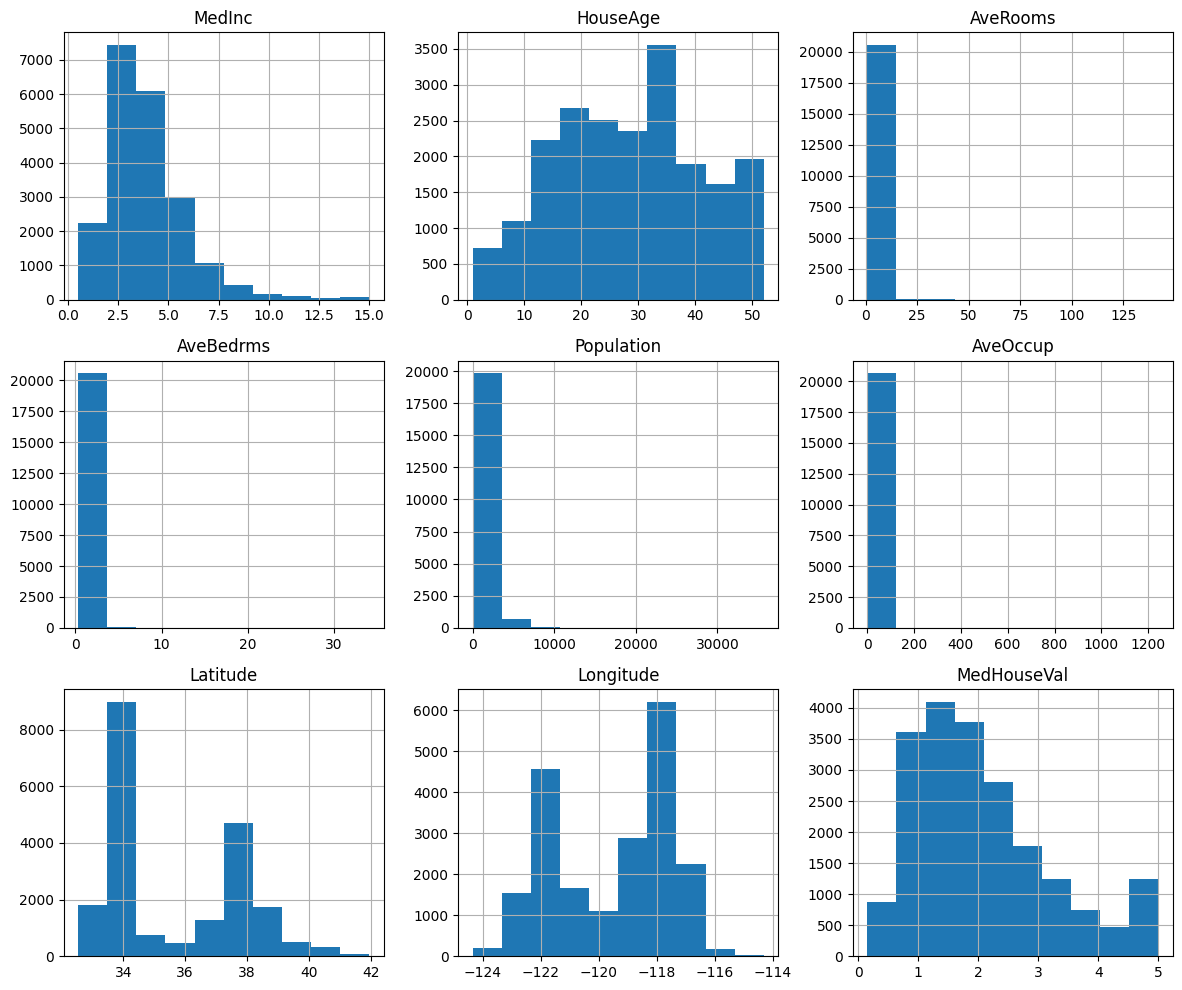

In [7]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

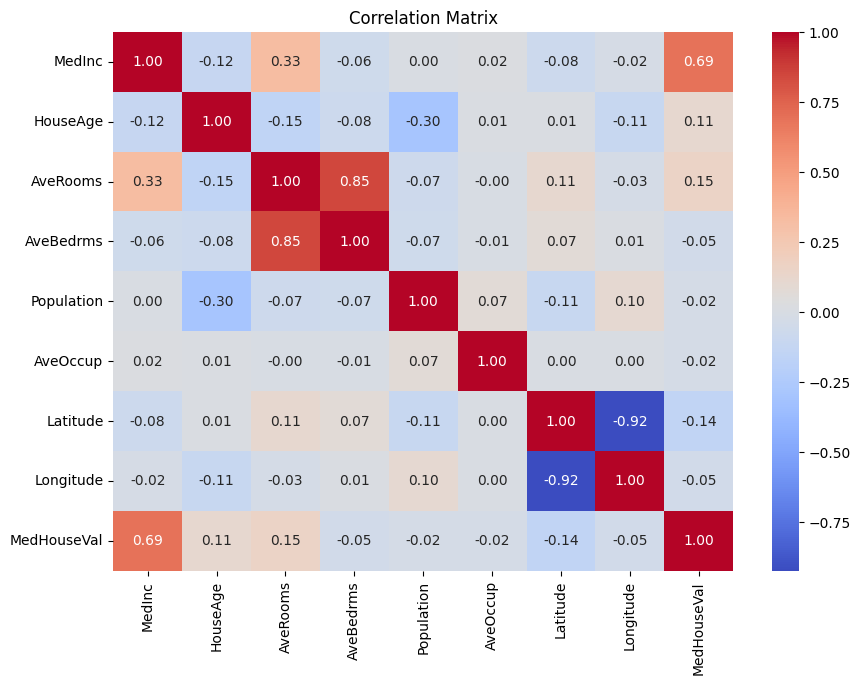

In [8]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

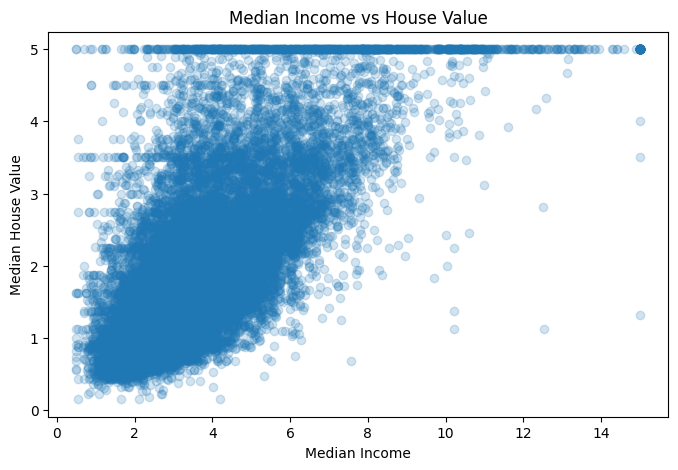

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["MedInc"],
    df["MedHouseVal"],
    alpha=0.2
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs House Value")

plt.show()

In [10]:
X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred = model.predict(X_test)
print(y_pred[:10])
print(y_test.iloc[:10].values)

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]
[0.477   0.458   5.00001 2.186   2.78    1.587   1.982   1.575   3.4
 4.466  ]


In [15]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 0.5332001304956555


In [16]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 0.5558915986952442


In [17]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.7455813830127763


In [18]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


In [19]:
print("Intercept:", model.intercept_)

Intercept: -37.02327770606416


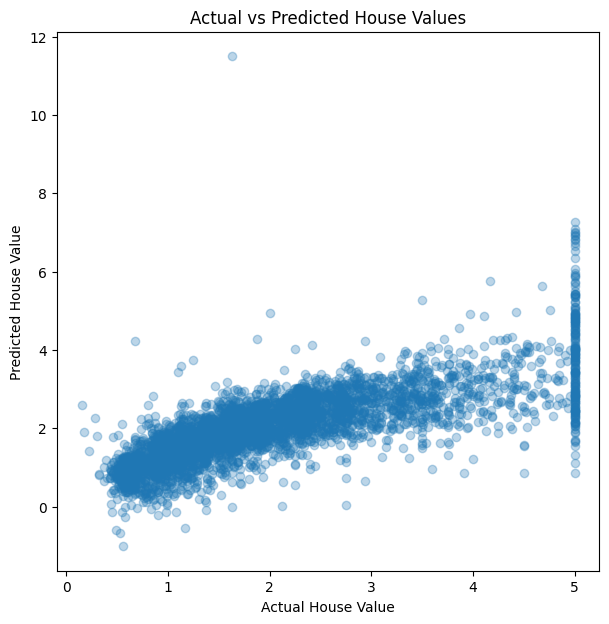

In [20]:
plt.figure(figsize=(7, 7))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

In [21]:
from sklearn.metrics import r2_score

In [22]:
r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: 0.575787706032451


In [23]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R²  :", r2)

In [24]:
evaluate_model(model, X_test, y_test)

MAE : 0.5332001304956555
MSE : 0.5558915986952442
RMSE: 0.7455813830127763
R²  : 0.575787706032451


Implement Simple Linear Regression

In [25]:
X_simple = df[["MedInc"]]
y = df["MedHouseVal"]

In [26]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
simple_model = LinearRegression()

simple_model.fit(X_train_s, y_train_s)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
y_pred_s = simple_model.predict(X_test_s)

In [29]:
print("MAE :", mean_absolute_error(y_test_s, y_pred_s))
print("MSE :", mean_squared_error(y_test_s, y_pred_s))
print("RMSE:", np.sqrt(mean_squared_error(y_test_s, y_pred_s)))
print("R²  :", r2_score(y_test_s, y_pred_s))

MAE : 0.629908653009376
MSE : 0.7091157771765548
RMSE: 0.8420901241414454
R²  : 0.45885918903846656


Polynomial Regression

In [30]:
from sklearn.preprocessing import PolynomialFeatures

In [31]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_s)
X_test_poly = poly.transform(X_test_s)

In [32]:
poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train_s)

y_pred_poly = poly_model.predict(X_test_poly)

In [34]:
print("MAE :", mean_absolute_error(y_test_s, y_pred_poly))
print("MSE :", mean_squared_error(y_test_s, y_pred_poly))
print("RMSE:", np.sqrt(mean_squared_error(y_test_s, y_pred_poly)))
print("R²  :", r2_score(y_test_s, y_pred_poly))

MAE : 0.6282915588701903
MSE : 0.7032732680932146
RMSE: 0.8386138969115731
R²  : 0.46331772769346213


Ridge Regression

In [35]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
evaluate_model(ridge_model, X_test, y_test)

MAE : 0.5332039182571148
MSE : 0.5558034669932211
RMSE: 0.7455222779992702
R²  : 0.5758549611440126


Lasso Regression

In [36]:
from sklearn.linear_model import Lasso
lasso_model=Lasso(alpha=0.01)
lasso_model.fit(X_train,y_train)
evaluate_model(lasso_model, X_test, y_test)


MAE : 0.536250464566337
MSE : 0.544449158124652
RMSE: 0.7378679815011978
R²  : 0.5845196673976367


Compairing all

In [37]:
results = []

models = {
    "Multiple Linear": model,
    "Ridge": ridge_model,
    "Lasso": lasso_model
}

for name, m in models.items():
    pred = m.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "MSE": mean_squared_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R2
0,Multiple Linear,0.533200,0.555892,0.745581,0.575788
1,Ridge,0.533204,0.555803,0.745522,0.575855
2,Lasso,0.536250,0.544449,0.737868,0.584520


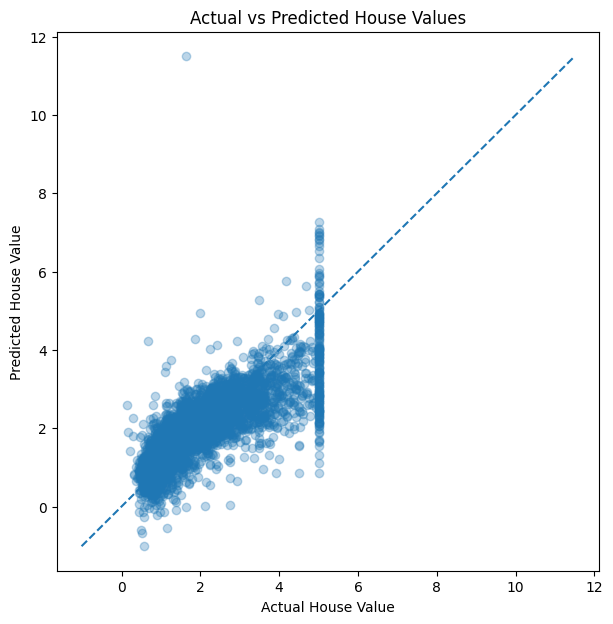

In [38]:
plt.figure(figsize=(7, 7))

plt.scatter(y_test, y_pred, alpha=0.3)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

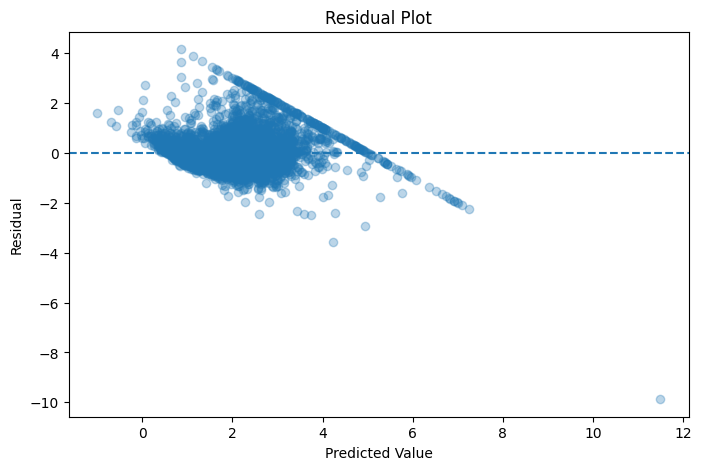

In [39]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals, alpha=0.3)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Value")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

Interpreting your model


In [40]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print("Intercept:", model.intercept_)

Intercept: -37.02327770606416


Multiple Linear Regression was evaluated using MAE, MSE, RMSE and R². Ridge and Lasso were also compared to examine the effect of regularization. The models showed different performance characteristics, and the final model was selected based on the evaluation results and generalization considerations.